<a href="https://colab.research.google.com/github/oxedanda/pml_final_project/blob/main/notebooks/04_future_forecast_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimental Future Wine Production Simulator
## Forecasting the 2026/27 campaign by Portuguese viticultural region

This notebook makes a genuine one-year-ahead forecast. It uses only information available before the target campaign: regional production lags, the recent three-year mean, the latest production trend, vineyard area, region, and year.

Model selection uses rolling-origin validation over 2018-2022. Campaigns 2023-2025 are retained for a final one-step-ahead test. The simulator is experimental: its uncertainty interval is based on historical validation errors and is not a guarantee.

In [1]:
# prompt: Set up this Colab notebook reproducibly without deleting the existing notebook 03.
from pathlib import Path

REPO_DIR = Path("/content/pml_final_project")
if REPO_DIR.exists():
    %cd /content/pml_final_project
    !git pull --ff-only
else:
    !git clone https://github.com/oxedanda/pml_final_project.git /content/pml_final_project
    %cd /content/pml_final_project

!pip -q install -r requirements.txt

Cloning into '/content/pml_final_project'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 254 (delta 33), reused 33 (delta 11), pack-reused 181 (from 1)
Receiving objects: 100% (254/254), 2.52 MiB | 10.03 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/pml_final_project
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 910.8/910.8 kB 53

## 1. Build lagged features and evaluate candidate models

For each target campaign, `production_lag_1`, `production_lag_2`, and the rolling mean are calculated from earlier campaigns only. The evaluation therefore does not reveal the target value to the model.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.future_forecast import (
    evaluate_forecasters,
    forecast_2026,
    load_history,
)

evaluation = evaluate_forecasters()
print("Selected on rolling validation:", evaluation.selected_model)
print(f"Empirical 90% interval half-width: {evaluation.interval_half_width:,.0f} hl")

Selected on rolling validation: Random forest with lags
Empirical 90% interval half-width: 147,976 hl


In [3]:
validation_metrics = (
    evaluation.metrics
    .query("split == 'rolling_validation_2018_2022'")
    .sort_values("MAE")
)
test_metrics = (
    evaluation.metrics
    .query("split == 'test_2023_2025'")
    .sort_values("MAE")
)

print("Rolling validation: 2018-2022")
display(validation_metrics[["model", "MAE", "RMSE", "R2"]])
print("Final one-step-ahead test: 2023-2025")
display(test_metrics[["model", "MAE", "RMSE", "R2"]])

Rolling validation: 2018-2022


,model,MAE,RMSE,R2
5,Random forest with lags,52313.734009,80663.734301,0.972565
2,Ridge with lags (alpha=0.1),55433.814399,80138.724226,0.972921
3,Ridge with lags (alpha=1),56040.411133,81925.875083,0.971700
4,Ridge with lags (alpha=10),56307.885754,84513.510940,0.969884
1,Linear regression with lags,62814.128115,85940.130090,0.968859
0,Persistence (previous campaign),70220.128571,115756.308192,0.943502


Final one-step-ahead test: 2023-2025


,model,MAE,RMSE,R2
11,Random forest with lags,59025.881929,100229.857411,0.960238
6,Persistence (previous campaign),69402.571429,126722.548781,0.936440
10,Ridge with lags (alpha=10),78820.684442,124083.002858,0.939061
9,Ridge with lags (alpha=1),81914.466858,128747.564580,0.934393
8,Ridge with lags (alpha=0.1),83055.267035,122432.743500,0.940671
7,Linear regression with lags,88247.841299,120599.808719,0.942434


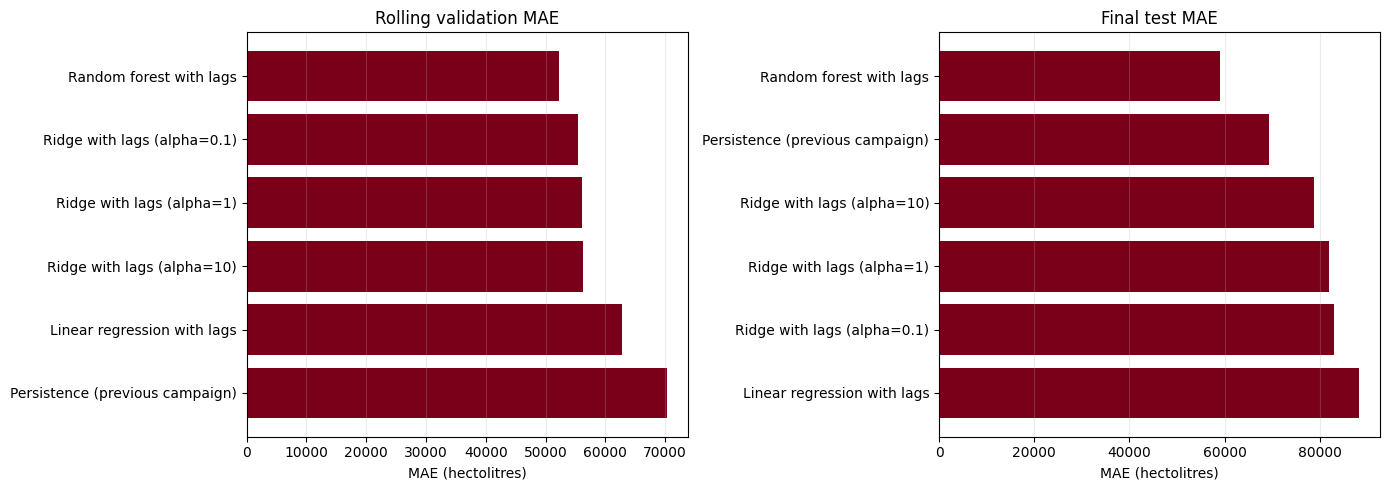

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, table, title in [
    (axes[0], validation_metrics, "Rolling validation MAE"),
    (axes[1], test_metrics, "Final test MAE"),
]:
    axis.barh(table["model"], table["MAE"], color="#7a0019")
    axis.invert_yaxis()
    axis.set_xlabel("MAE (hectolitres)")
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 2. Forecast all regions for 2026/27

The default scenario assumes that 2026 vineyard area remains equal to the latest available area for each region. This assumption can be changed in the interactive simulator below.

In [5]:
future_forecasts = forecast_2026(evaluation)
display(future_forecasts.style.format({
    "vineyard_area_ha": "{:,.0f}",
    "predicted_production_hl": "{:,.0f}",
    "lower_90_hl": "{:,.0f}",
    "upper_90_hl": "{:,.0f}",
}))

,region,year_start,vineyard_area_ha,selected_model,predicted_production_hl,lower_90_hl,upper_90_hl
0,Alentejo,2026,"25,422",Random forest with lags,"1,068,766","920,791","1,216,742"
1,Algarve,2026,"1,202",Random forest with lags,"18,255",0,"166,231"
2,Açores,2026,"1,334",Random forest with lags,"10,151",0,"158,127"
3,Bairrada,2026,"9,181",Random forest with lags,"188,368","40,393","336,344"
4,Beira Interior,2026,"11,361",Random forest with lags,"219,067","71,091","367,043"
5,Douro,2026,"43,930",Random forest with lags,"1,411,028","1,263,052","1,559,003"
6,Dão,2026,"9,834",Random forest with lags,"218,304","70,328","366,279"
7,Lisboa,2026,"17,820",Random forest with lags,"1,166,580","1,018,605","1,314,556"
8,Madeira,2026,646,Random forest with lags,"28,790",0,"176,765"
9,P. Setúbal,2026,"7,355",Random forest with lags,"477,691","329,716","625,667"


## 3. Interactive regional scenario

Choose a region and optionally change its expected vineyard area. The model is refitted on all supervised observations through 2025 before producing the 2026/27 estimate.

In [6]:
# prompt: Add a small transparent interface for region and vineyard-area scenarios.
import ipywidgets as widgets

history = load_history()
latest_area = (
    history.dropna(subset=["vineyard_area_ha"])
    .sort_values("year_start")
    .groupby("region", observed=True)
    .tail(1)
    .set_index("region")["vineyard_area_ha"]
)

region_widget = widgets.Dropdown(
    options=sorted(latest_area.index),
    description="Region:",
)
area_widget = widgets.FloatText(
    value=float(latest_area.loc[region_widget.value]),
    description="Area (ha):",
)
forecast_button = widgets.Button(description="Forecast 2026/27", button_style="primary")
forecast_output = widgets.Output()

def update_default_area(change):
    area_widget.value = float(latest_area.loc[change["new"]])

def show_forecast(_button):
    with forecast_output:
        forecast_output.clear_output()
        result = forecast_2026(
            evaluation,
            area_overrides={region_widget.value: area_widget.value},
        )
        row = result[result["region"] == region_widget.value]
        display(row.style.format({
            "vineyard_area_ha": "{:,.0f}",
            "predicted_production_hl": "{:,.0f}",
            "lower_90_hl": "{:,.0f}",
            "upper_90_hl": "{:,.0f}",
        }))

region_widget.observe(update_default_area, names="value")
forecast_button.on_click(show_forecast)
display(widgets.VBox([region_widget, area_widget, forecast_button, forecast_output]))

## Interpretation and limitations

- This is a one-year-ahead experimental forecast, not a guaranteed production value.
- The model uses actual production from the preceding campaign, so it should be rerun when newer official IVV data become available.
- The 90% interval is an empirical error band derived from rolling-validation absolute errors; it is not a formal probabilistic confidence interval.
- Weather, disease pressure, management decisions, and other annual drivers are absent.
- Changing vineyard area creates a scenario, but it does not establish a causal effect.
- The persistence forecast remains visible in the evaluation so that the ML model is not presented without a meaningful reference.